# 🔍 EDA & Visualisasi Sinyal — Deteksi Wireless Jamming

Notebook ini melakukan eksplorasi data awal pada dataset DeepSig (`GOLD_XYZ_OSC.0001_1024.hdf5`):
1. Inspeksi struktur HDF5
2. Visualisasi sinyal I/Q: Time Domain, Constellation, PSD
3. Demonstrasi injeksi CW & Barrage Jamming
4. Analisis distribusi energi sinyal

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import h5py
import matplotlib.pyplot as plt
import importlib

# Import fungsi dari modul proyek
sys.path.insert(0, '../src')
data_gen = importlib.import_module('1_data_generator')
from src.utils import plot_time_domain, plot_constellation, plot_psd

plt.style.use('dark_background')
print('✅ Semua library berhasil di-import!')

✅ Semua library berhasil di-import!


## 1️⃣ Inspeksi Struktur Dataset HDF5

In [2]:
HDF5_PATH = '../data/GOLD_XYZ_OSC.0001_1024.hdf5'

with h5py.File(HDF5_PATH, 'r') as f:
    print('Keys dalam dataset:', list(f.keys()))
    for key in f.keys():
        print(f'  {key}: shape={f[key].shape}, dtype={f[key].dtype}')
    
    total_frames = f['X'].shape[0]
    seq_len = f['X'].shape[1]
    n_channels = f['X'].shape[2]
    
    print(f'\n📊 Ringkasan:')
    print(f'   Total frames: {total_frames:,}')
    print(f'   Sequence length: {seq_len}')
    print(f'   Channels (I/Q): {n_channels}')
    print(f'   Estimasi ukuran di RAM: {total_frames * seq_len * n_channels * 4 / 1e9:.2f} GB (float32)')

Keys dalam dataset: ['X', 'Y', 'Z']
  X: shape=(2555904, 1024, 2), dtype=float32
  Y: shape=(2555904, 24), dtype=int64
  Z: shape=(2555904, 1), dtype=int64

📊 Ringkasan:
   Total frames: 2,555,904
   Sequence length: 1024
   Channels (I/Q): 2
   Estimasi ukuran di RAM: 20.94 GB (float32)


## 2️⃣ Visualisasi Sinyal Normal (Tanpa Jamming)

Ambil beberapa contoh sinyal asli dan visualisasikan dalam 3 domain:
- **Time Domain**: Gelombang I/Q sepanjang waktu
- **Constellation Diagram**: Scatter plot I vs Q
- **PSD**: Power Spectral Density

In [3]:
# Ambil 5 sample acak
with h5py.File(HDF5_PATH, 'r') as f:
    sample_indices = np.random.choice(total_frames, 5, replace=False)
    samples = f['X'][sorted(sample_indices)]

print(f'Sample indices: {sorted(sample_indices)}')
print(f'Shape: {samples.shape}')

Sample indices: [np.int32(48935), np.int32(180797), np.int32(608295), np.int32(2190209), np.int32(2331244)]
Shape: (5, 1024, 2)


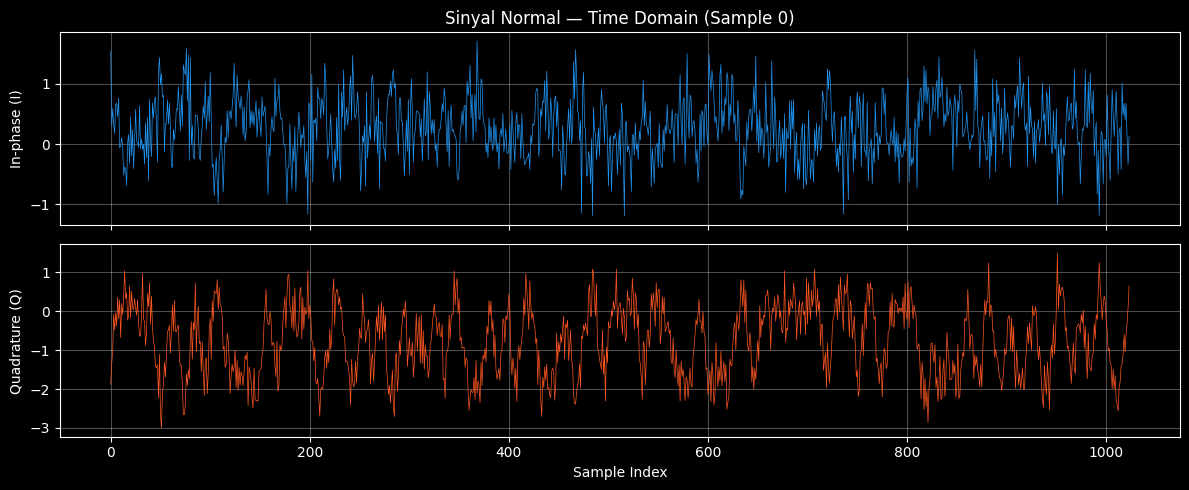

In [4]:
# Plot Time Domain untuk sample pertama
plot_time_domain(samples[0], title='Sinyal Normal — Time Domain (Sample 0)')

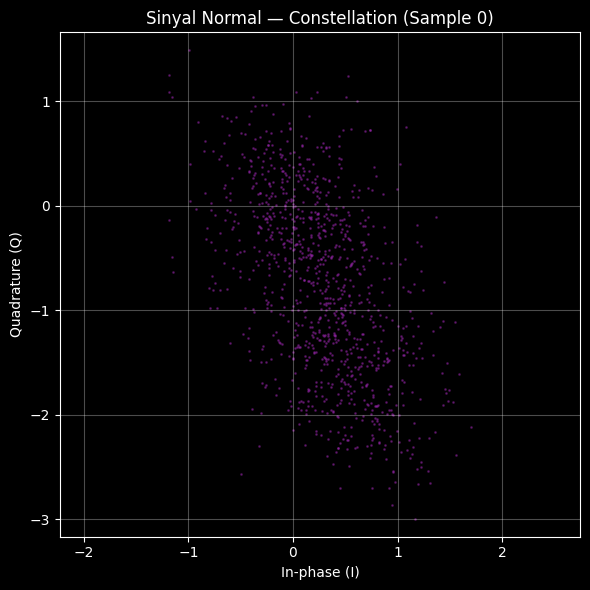

In [5]:
# Plot Constellation Diagram
plot_constellation(samples[0], title='Sinyal Normal — Constellation (Sample 0)')

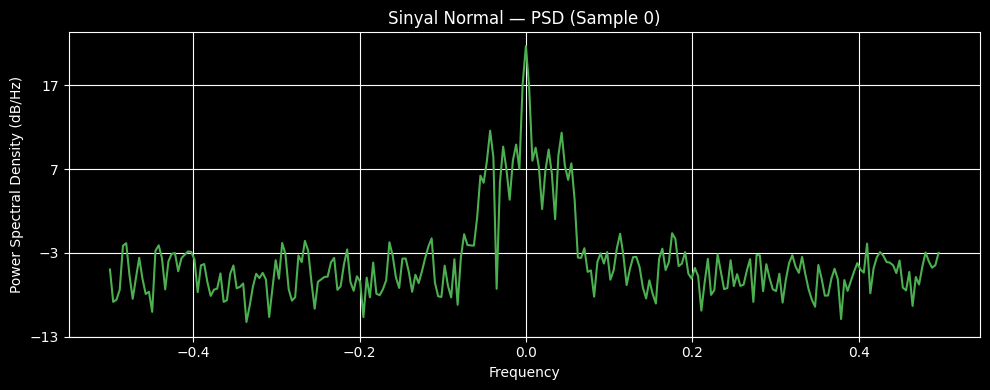

In [6]:
# Plot PSD
plot_psd(samples[0], title='Sinyal Normal — PSD (Sample 0)')

## 3️⃣ Demonstrasi Injeksi Jamming

Bandingkan sinyal normal vs sinyal setelah diinjeksi CW & Barrage pada berbagai SJR.

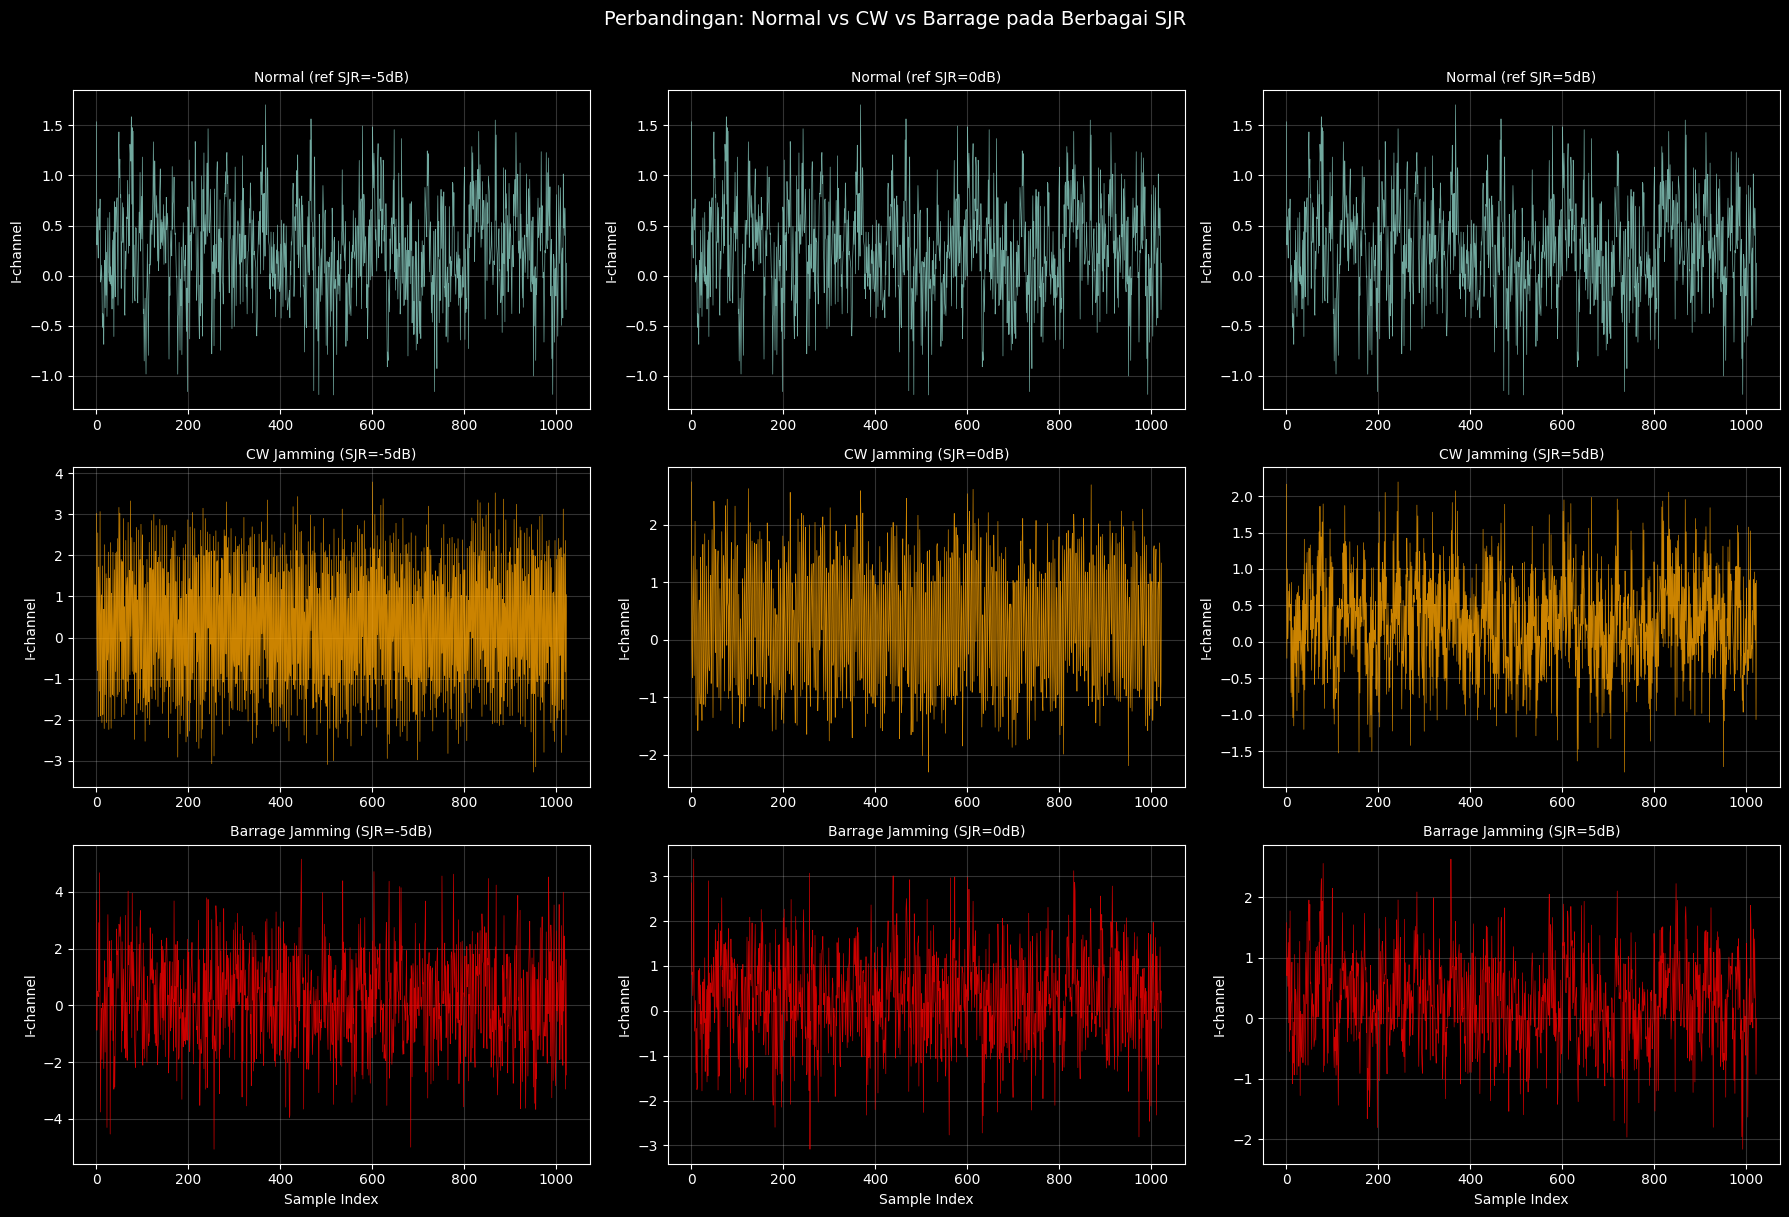

In [7]:
# Pilih satu sinyal untuk demonstrasi
original = samples[0].copy()

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
sjr_values = [-5, 0, 5]

for col, sjr in enumerate(sjr_values):
    # Normal
    axes[0, col].plot(original[:, 0], linewidth=0.5, alpha=0.8)
    axes[0, col].set_title(f'Normal (ref SJR={sjr}dB)', fontsize=10)
    axes[0, col].set_ylabel('I-channel')
    axes[0, col].grid(True, alpha=0.2)
    
    # CW Jamming
    cw_jammed = data_gen.inject_cw_jamming(original, sjr)
    axes[1, col].plot(cw_jammed[:, 0], linewidth=0.5, alpha=0.8, color='orange')
    axes[1, col].set_title(f'CW Jamming (SJR={sjr}dB)', fontsize=10)
    axes[1, col].set_ylabel('I-channel')
    axes[1, col].grid(True, alpha=0.2)
    
    # Barrage Jamming
    barrage_jammed = data_gen.inject_barrage_jamming(original, sjr)
    axes[2, col].plot(barrage_jammed[:, 0], linewidth=0.5, alpha=0.8, color='red')
    axes[2, col].set_title(f'Barrage Jamming (SJR={sjr}dB)', fontsize=10)
    axes[2, col].set_ylabel('I-channel')
    axes[2, col].set_xlabel('Sample Index')
    axes[2, col].grid(True, alpha=0.2)

plt.suptitle('Perbandingan: Normal vs CW vs Barrage pada Berbagai SJR', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4️⃣ Analisis Distribusi Energi Sinyal

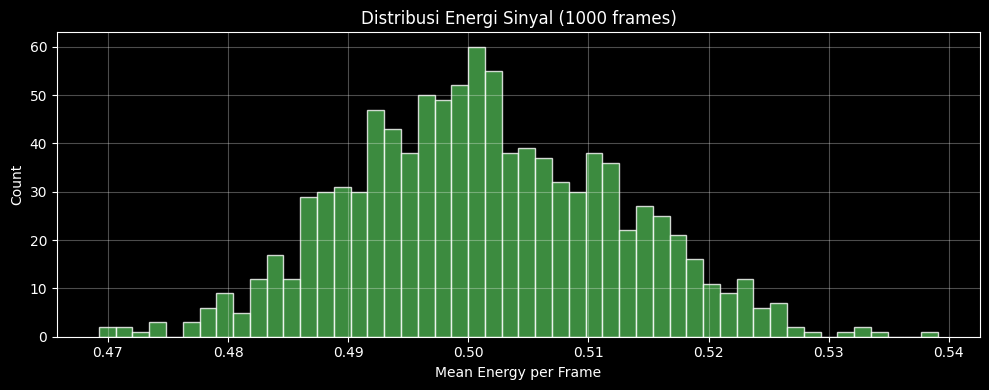

Energi — Min: 0.469249, Max: 0.539098, Mean: 0.501254


In [8]:
# Hitung energi dari beberapa sample
n_analysis = min(1000, total_frames)

with h5py.File(HDF5_PATH, 'r') as f:
    analysis_samples = f['X'][:n_analysis]

energies = np.mean(analysis_samples ** 2, axis=(1, 2))

plt.figure(figsize=(10, 4))
plt.hist(energies, bins=50, color='#4CAF50', alpha=0.8, edgecolor='white')
plt.xlabel('Mean Energy per Frame')
plt.ylabel('Count')
plt.title(f'Distribusi Energi Sinyal ({n_analysis} frames)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Energi — Min: {energies.min():.6f}, Max: {energies.max():.6f}, Mean: {energies.mean():.6f}')

## 5️⃣ Test Data Generator

Verifikasi bahwa `JammingDataGenerator` menghasilkan distribusi label yang seimbang.

[Split] Total: 3000 | Train: 2100 | Val: 450 | Test: 450


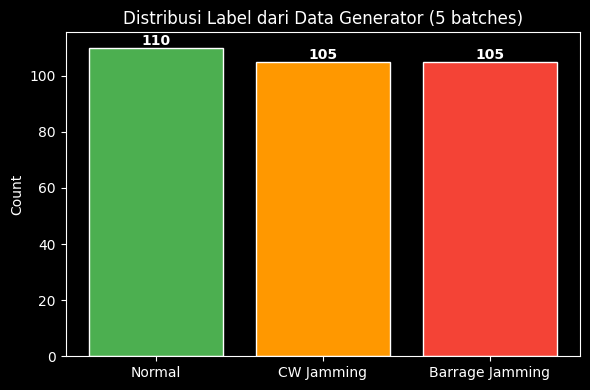

Total samples: 320
Normal: 110 (34.4%)
CW:     105 (32.8%)
Barrage:105 (32.8%)


In [9]:
from src.data_loader import JammingDataGenerator, create_train_val_test_split

train_idx, val_idx, test_idx = create_train_val_test_split(max_samples=3000)
gen = JammingDataGenerator(indices=train_idx, batch_size=64)

# Ambil beberapa batch dan hitung distribusi label
all_labels = []
for i in range(min(5, len(gen))):
    X, y = gen[i]
    all_labels.extend(y)

all_labels = np.array(all_labels)
counts = np.bincount(all_labels, minlength=3)

plt.figure(figsize=(6, 4))
bars = plt.bar(['Normal', 'CW Jamming', 'Barrage Jamming'], counts,
               color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='white')
plt.ylabel('Count')
plt.title('Distribusi Label dari Data Generator (5 batches)')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total samples: {len(all_labels)}')
print(f'Normal: {counts[0]} ({counts[0]/len(all_labels)*100:.1f}%)')
print(f'CW:     {counts[1]} ({counts[1]/len(all_labels)*100:.1f}%)')
print(f'Barrage:{counts[2]} ({counts[2]/len(all_labels)*100:.1f}%)')